# Merge Christenson's English Chapter Titles and K'iche' Text in Definitive Form

In [1]:
import pandas as pd
import numpy as np

# Import Christenson CHAP

In [2]:
CHAP = pd.read_csv("christenson-CHAP.csv").set_index('chap_num')

In [3]:
CHAP['n_lines'] = CHAP.xom_end_fixed - CHAP.xom_start_fixed + 1

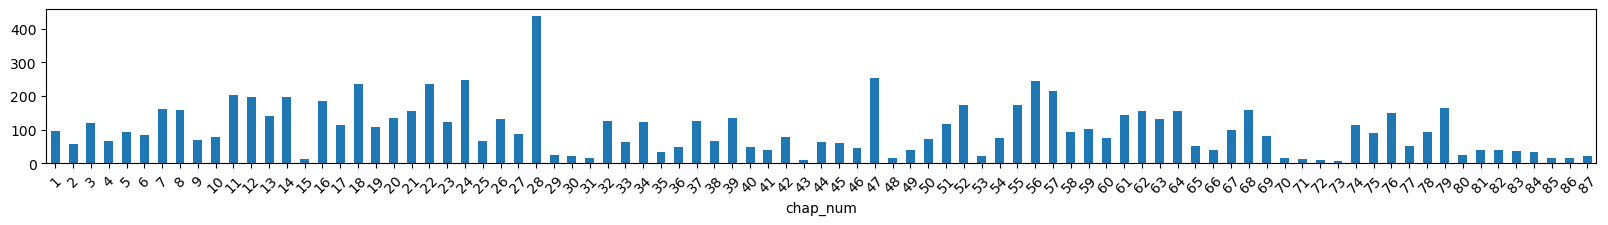

In [4]:
CHAP.n_lines.plot.bar(figsize=(20,2), rot=45);

In [5]:
CHAP.n_lines.sum()

8727

In [6]:
CHAP

,chap_title,page_num,xom_start,xom_end,xom_start_fixed,xom_end_fixed,n_lines
chap_num,,,,,,,
1,Preamble,59,1,96,1,96,96
2,The Primordial World,67,97,154,97,154,58
3,The Creation of the Earth,70,155,274,155,274,120
4,The Creation of the Animals,74,275,339,275,339,65
5,The Fall of the Animals,76,340,433,340,433,94
...,...,...,...,...,...,...,...
83,The Dynasty of Nihaib Lords,301,8596,8631,8606,8641,36
84,The Great Houses of the Nihaib Lords,302,8632,8663,8642,8673,32
85,The Dynasty of Ahau Quiché Lords,303,8664,8679,8674,8689,16


# Import Christenson LINE

In [7]:
LINE = pd.read_csv("christenson-LINE_LITERAL.csv").set_index(['line_num'])

In [8]:
LINE

,eng_str,quc_str,line_marker
line_num,,,
1,"THIS ITS ROOT ANCIENT WORD,","ARE' U XE' OJER TZIJ,",NaN
2,Here Quiché its name.,Waral K'iche' u b'i'.,NaN
3,"HERE we shall write,","WARAL xchiqatz'ib'aj wi,",NaN
4,"We shall plant ancient word,","Xchiqatikib'a' wi ojer tzij,",NaN
5,"Its planting,","U tikarib'al,",NaN
...,...,...,...
8722,This because not now means of sight of it.,Ri' rumal maja b'i chi ilb'al re.,NaN
8723,There is first anciently by lords.,K'o nab'e ojer kumal ajawab'.,NaN
8724,Lost now.,Sachinaq chik.,NaN


In [9]:
len(LINE)

8726

# Combine

In [10]:
CHAP_LINE = CHAP.reset_index().merge(LINE, right_on='line_num', left_on='xom_start_fixed', how='right')

In [11]:
CHAP_LINE.head()

,chap_num,chap_title,page_num,xom_start,xom_end,xom_start_fixed,xom_end_fixed,n_lines,eng_str,quc_str,line_marker
0,1.0,Preamble,59.0,1.0,96.0,1.0,96.0,96.0,"THIS ITS ROOT ANCIENT WORD,","ARE' U XE' OJER TZIJ,",NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Here Quiché its name.,Waral K'iche' u b'i'.,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"HERE we shall write,","WARAL xchiqatz'ib'aj wi,",NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"We shall plant ancient word,","Xchiqatikib'a' wi ojer tzij,",NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Its planting,","U tikarib'al,",NaN


In [12]:
CHAP_LINE.chap_num = CHAP_LINE.chap_num.ffill()
CHAP_LINE.chap_num = CHAP_LINE.chap_num.astype(int)
CHAP_LINE = CHAP_LINE.reset_index()
CHAP_LINE = CHAP_LINE.rename(columns={'index':'line_num'})
CHAP_LINE.line_num = CHAP_LINE.line_num + 1

In [13]:
OHCO = ['chap_num','line_num']
CHAP_LINE = CHAP_LINE.set_index(OHCO)

In [14]:
CHAP_LINE

chap_title  page_num  xom_start  xom_end  xom_start_fixed  \
chap_num line_num                                                             
1        1          Preamble      59.0        1.0     96.0              1.0   
         2               NaN       NaN        NaN      NaN              NaN   
         3               NaN       NaN        NaN      NaN              NaN   
         4               NaN       NaN        NaN      NaN              NaN   
         5               NaN       NaN        NaN      NaN              NaN   
...                      ...       ...        ...      ...              ...   
87       8722            NaN       NaN        NaN      NaN              NaN   
         8723            NaN       NaN        NaN      NaN              NaN   
         8724            NaN       NaN        NaN      NaN              NaN   
         8725            NaN       NaN        NaN      NaN              NaN   
         8726            NaN       NaN        NaN      NaN              NaN   

                   xom_end_fixed  n_lines  \
chap_num line_num                           
1        1                  96.0     96.0   
         2                   NaN      NaN   
         3                   NaN      NaN   
         4                   NaN      NaN   
         5                   NaN      NaN   
...                          ...      ...   
87       8722                NaN      NaN   
         8723                NaN      NaN   
         8724                NaN      NaN   
         8725                NaN      NaN   
         8726                NaN      NaN   

                                                            eng_str  \
chap_num line_num                                                     
1        1                              THIS ITS ROOT ANCIENT WORD,   
         2                                    Here Quiché its name.   
         3                                     HERE we shall write,   
         4                             We shall plant ancient word,   
         5                                            Its planting,   
...                                                             ...   
87       8722            This because not now means of sight of it.   
         8723                    There is first anciently by lords.   
         8724                                             Lost now.   
         8725      But therefore this was completed now all Quiché,   
         8726                                   Sta. Cruz its name.   

                                                         quc_str  line_marker  
chap_num line_num                                                              
1        1                                 ARE' U XE' OJER TZIJ,          NaN  
         2                                 Waral K'iche' u b'i'.          NaN  
         3                              WARAL xchiqatz'ib'aj wi,          NaN  
         4                          Xchiqatikib'a' wi ojer tzij,          NaN  
         5                                         U tikarib'al,          NaN  
...                                                          ...          ...  
87       8722                  Ri' rumal maja b'i chi ilb'al re.          NaN  
         8723                      K'o nab'e ojer kumal ajawab'.          NaN  
         8724                                     Sachinaq chik.          NaN  
         8725      Xere k'u ri' mi xutzinik chi konojel K'iche',          NaN  
         8726                                  Sta. Cruz u b'i'.          NaN  

[8726 rows x 10 columns]

In [15]:
CHAP_LINE_SIMPLE = CHAP_LINE[['eng_str','quc_str']].copy()

In [16]:
CHAP_LINE_SIMPLE.quc_str = CHAP_LINE_SIMPLE.quc_str.astype(str)
CHAP_LINE_SIMPLE.eng_str = CHAP_LINE_SIMPLE.eng_str.astype(str)

In [17]:
CHAP_LINE_SIMPLE.loc[22].head(20)

,eng_str,quc_str
line_num,,
2664,THIS now we shall relate,ARE' chik xchiqatzijoj
2665,Their birth,Kalaxik
2666,"Hunahpu,","Junajpu,"
2667,Xbalanque.,Xb'alanke.
2668,"THIS therefore their birth,","ARE' k'ut kalaxik,"
2669,This we shall tell,Wa'e xchiqab'ij
2670,Then she found its day,Ta xuriq u q'ij
2671,"Their birth,","Kalaxik,"
2672,"Then she gave birth also the maiden,","Ta xalan puch ri q'apoj,"


In [18]:
CHAP['chap_eng_str'] = CHAP_LINE_SIMPLE.groupby('chap_num').eng_str.apply(lambda x: ' '.join(x))
CHAP['chap_quc_str'] = CHAP_LINE_SIMPLE.groupby('chap_num').quc_str.apply(lambda x: ' '.join(x))

In [19]:
CHAP

,chap_title,page_num,xom_start,xom_end,xom_start_fixed,xom_end_fixed,n_lines,chap_eng_str,chap_quc_str
chap_num,,,,,,,,,
1,Preamble,59,1,96,1,96,96,"THIS ITS ROOT ANCIENT WORD, Here Quiché its na...","ARE' U XE' OJER TZIJ, Waral K'iche' u b'i'. WA..."
2,The Primordial World,67,97,154,97,154,58,THIS ITS ACCOUNT These things. Still be it sil...,"ARE' U TZIJOXIK Wa'e. K'a katz'ininoq, K'a kac..."
3,The Creation of the Earth,70,155,274,155,274,120,"THEN came therefore his word here, He arrived ...","TA xpe k'ut u tzij waral, Xul kuk' Ri Tepew, Q..."
4,The Creation of the Animals,74,275,339,275,339,65,THEN they conceived again Its animals mountain...,"TA xkino'jij chik U chikopil juyub', Chajal re..."
5,The Fall of the Animals,76,340,433,340,433,94,"THEN it was said to again therefore the deer, ...","TA xe'uchax chi k'ut ri kiej, Tz'ikin Rumal Tz..."
...,...,...,...,...,...,...,...,...,...
83,The Dynasty of Nihaib Lords,301,8596,8631,8606,8641,36,"THESE therefore of Nihaib, Nine on its top of ...","WA' k'ute rech Nijaib'ab', B'elejeb' chiwi' ch..."
84,The Great Houses of the Nihaib Lords,302,8632,8663,8642,8673,32,THESE therefore next all lords Having come out...,ARE' k'u ri' chi ronojel ajawab' Elenaq chirij...
85,The Dynasty of Ahau Quiché Lords,303,8664,8679,8674,8689,16,THESE next therefore Of Ahau Quichés: This the...,"ARE' chi k'ut Rech Ajaw K'iche': Wa' u mam, U ..."


# TOKEN

In [20]:
import re

In [21]:
TOKEN_QUC = CHAP_LINE_SIMPLE.quc_str.apply(lambda x: re.findall(r"(?u)\b\w[\w']*\b", x)).apply(pd.Series).stack().to_frame('token_str')
TOKEN_QUC['term_str'] = TOKEN_QUC.token_str.str.lower()
TOKEN_QUC.index.names = ['chap_num','line_num','token_num']

In [22]:
TOKEN_QUC

token_str term_str
chap_num line_num token_num                   
1        1        0               ARE      are
                  1                 U        u
                  2                XE       xe
                  3              OJER     ojer
                  4              TZIJ     tzij
...                               ...      ...
87       8725     7            K'iche   k'iche
         8726     0               Sta      sta
                  1              Cruz     cruz
                  2                 u        u
                  3               b'i      b'i

[29383 rows x 2 columns]

# VOCAB

In [23]:
CTM = TOKEN_QUC.groupby(['chap_num','term_str']).term_str.count().unstack(fill_value=0)

In [24]:
CTM

term_str,a,a'on,ab'aj,ab'ajil,ab'anel,ab'ix,ab'ixik,ab'ixom,achaq,achb'ilan,...,yojol,yolkwat,yoq,yoq'b'al,yoq'otaj,yoq'otajinaq,yujuj,yuq,yuyub,zuywa
chap_num,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
84,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
85,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
VOCAB = CTM.sum().to_frame('n') # TOKEN_QUC.term_str.value_counts().to_frame('n')
VOCAB['df'] = CTM.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(len(CTM)/VOCAB.df)

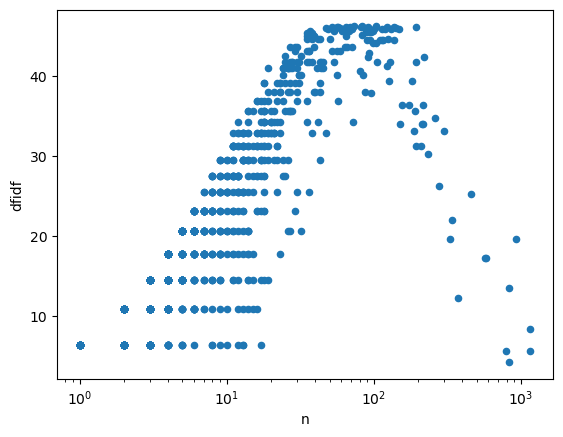

In [26]:
VOCAB.plot.scatter('n','dfidf', logx=True);

In [27]:
VOCAB[VOCAB.dfidf >= 10]

,n,df,dfidf
term_str,,,
a,36,21,43.063148
a'on,2,2,10.885887
ab'aj,31,19,41.705304
ab'ix,6,2,10.885887
achb'ilay,2,2,10.885887
...,...,...,...
yaki,7,4,17.771774
yakolatam,2,2,10.885887
yamanik,5,5,20.605077


In [28]:
VOCAB[VOCAB.n > 300].sort_values('dfidf')

,n,df,dfidf
term_str,,,
k'ut,836,84,4.252590
chi,795,83,5.636037
u,1161,83,5.636037
ri,1151,81,8.350573
are,371,78,12.288220
ki,828,77,13.564086
wi,567,74,17.278270
xa,579,74,17.278270
b'i,330,72,19.657332


# Save

In [30]:
CHAP_LINE_SIMPLE.to_csv("christenson-LINE_LITERAL-with-chaps.csv", index=True)
CHAP.to_csv("christenson-CHAP-with-text.csv", index=True)
TOKEN_QUC.to_csv("christenson-TOKEN_QUC.csv", index=True)
VOCAB.to_csv("christenson-VOCAB.csv", index=True)